In [1]:
import sys, warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11

ROOT = Path('.').resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.features import engineer_features, build_preprocessor, NUMERIC_FEATURES, CATEGORICAL_FEATURES, LOG_TARGET

PROCESSED_PATH = ROOT / 'data' / 'processed_dataset.csv'
FIGURES = ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

SUBURB_PALETTE = {'Surry Hills': '#E07B54', 'Parramatta': '#5B8DB8', 'Penrith': '#6DBF9E'}

df = pd.read_csv(PROCESSED_PATH, parse_dates=['sale_date'])
print(f'Loaded {len(df)} records.')
df.head(3)

Loaded 120 records.


,suburb,postcode,property_type,bedrooms,bathrooms,car_spaces,land_size_m2,floor_area_m2,year_built,sale_date,distance_to_cbd_km,agent_description,sale_price_aud,source_url
0,Penrith,2750,House,4,4,1,690.0,180.0,2009,2023-01-08,57.5,"Quiet street, close to schools",1406000,https://www.domain.com.au/example-penrith-035
1,Parramatta,2150,House,4,3,1,483.0,166.0,1984,2023-01-09,26.7,Spacious living with natural light,1447000,https://www.domain.com.au/example-parramatta-015
2,Penrith,2750,Townhouse,4,3,0,657.0,112.0,2001,2023-01-26,54.2,"North-facing aspect, excellent light",1224000,https://www.domain.com.au/example-penrith-030


---
## 2.1  Pre-Analysis Prediction

Before examining any correlation or distribution, I record my expectations about the three most influential features:

1. **`suburb`** — The three suburbs represent fundamentally different market segments with median prices roughly $1.25M (Surry Hills), $900K (Parramatta) and $680K (Penrith). This should be the single strongest predictor.
2. **`land_size_m2`** — For house properties, land is the primary driver of value. Even small increments of land in inner-ring suburbs command large premiums.
3. **`bedrooms` / `floor_area_m2`** — A proxy for dwelling size; strongly correlated with price once suburb is controlled.

These predictions will be revisited after modelling in Notebook 03.

---
## 2.2  Price Distribution — Overall

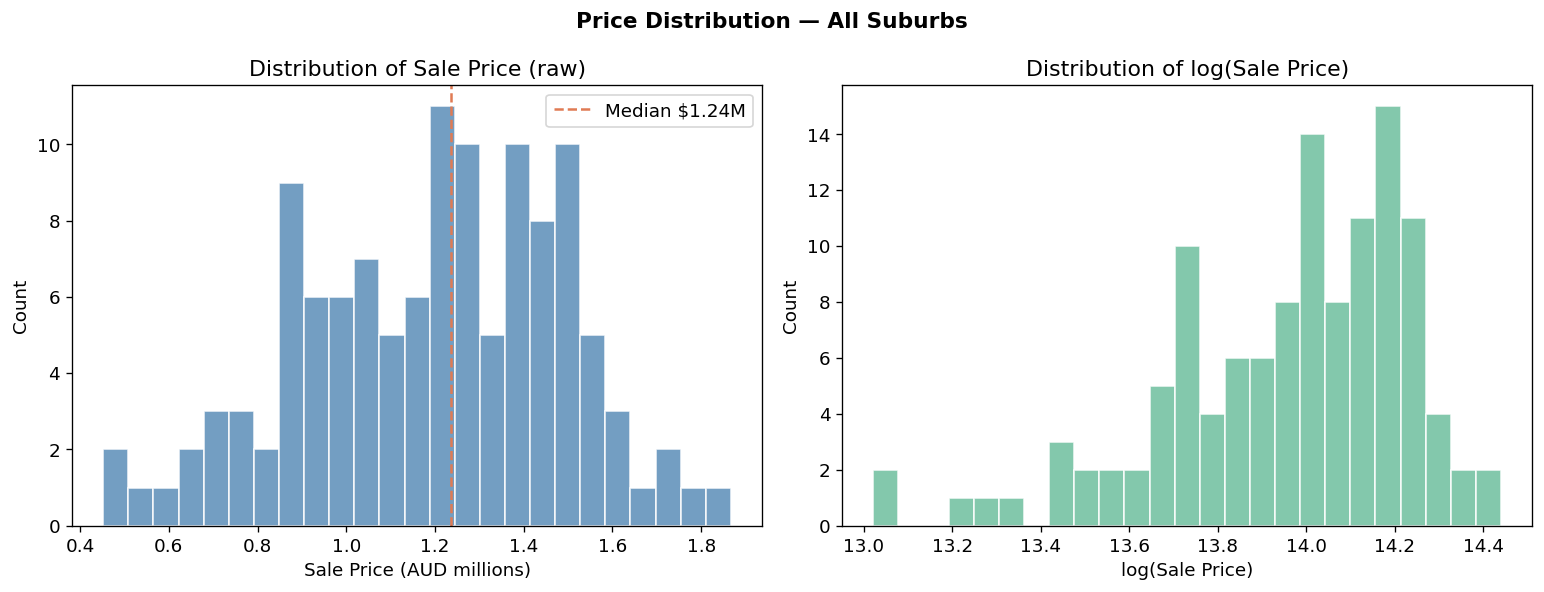

Skewness (raw):  -0.288
Skewness (log):  -0.979
→ Log transform substantially reduces right skew. Will use log(price) as target.


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw price
axes[0].hist(df['sale_price_aud'] / 1e6, bins=25, color='#5B8DB8', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Sale Price (AUD millions)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Sale Price (raw)')
axes[0].axvline(df['sale_price_aud'].median() / 1e6, color='#E07B54', linestyle='--', label=f'Median ${df["sale_price_aud"].median()/1e6:.2f}M')
axes[0].legend()

# Log price
axes[1].hist(np.log(df['sale_price_aud']), bins=25, color='#6DBF9E', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of log(Sale Price)')

plt.suptitle('Price Distribution — All Suburbs', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'price_distribution.png', bbox_inches='tight')
plt.show()

print(f"Skewness (raw):  {stats.skew(df['sale_price_aud']):.3f}")
print(f"Skewness (log):  {stats.skew(np.log(df['sale_price_aud'])):.3f}")
print('→ Log transform substantially reduces right skew. Will use log(price) as target.')

---
## 2.3  Price by Suburb — Box Plots

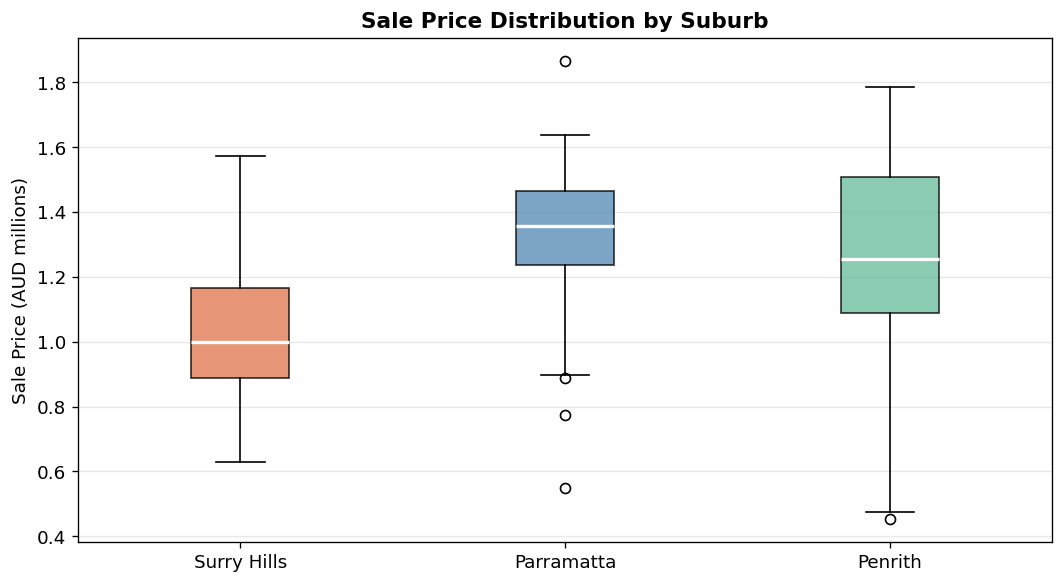

            count        mean       std       min         25%         50%  \
suburb                                                                      
Parramatta    $40  $1,313,050  $249,370  $550,000  $1,236,250  $1,357,000   
Penrith       $40  $1,246,300  $334,211  $452,000  $1,090,000  $1,253,500   
Surry Hills   $40  $1,022,550  $223,297  $629,000    $886,500    $997,500   

                    75%         max  
suburb                               
Parramatta   $1,465,000  $1,867,000  
Penrith      $1,507,500  $1,785,000  
Surry Hills  $1,165,250  $1,574,000  


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
suburbs_order = ['Surry Hills', 'Parramatta', 'Penrith']
data_plot = [df.loc[df['suburb'] == s, 'sale_price_aud'].values / 1e6 for s in suburbs_order]
bp = ax.boxplot(data_plot, labels=suburbs_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
colors = ['#E07B54', '#5B8DB8', '#6DBF9E']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_ylabel('Sale Price (AUD millions)')
ax.set_title('Sale Price Distribution by Suburb', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES / 'price_by_suburb_boxplot.png', bbox_inches='tight')
plt.show()

print(df.groupby('suburb')['sale_price_aud'].describe().applymap(lambda x: f'${x:,.0f}'))

---
## 2.4  Scatter Plots — Price vs Key Features

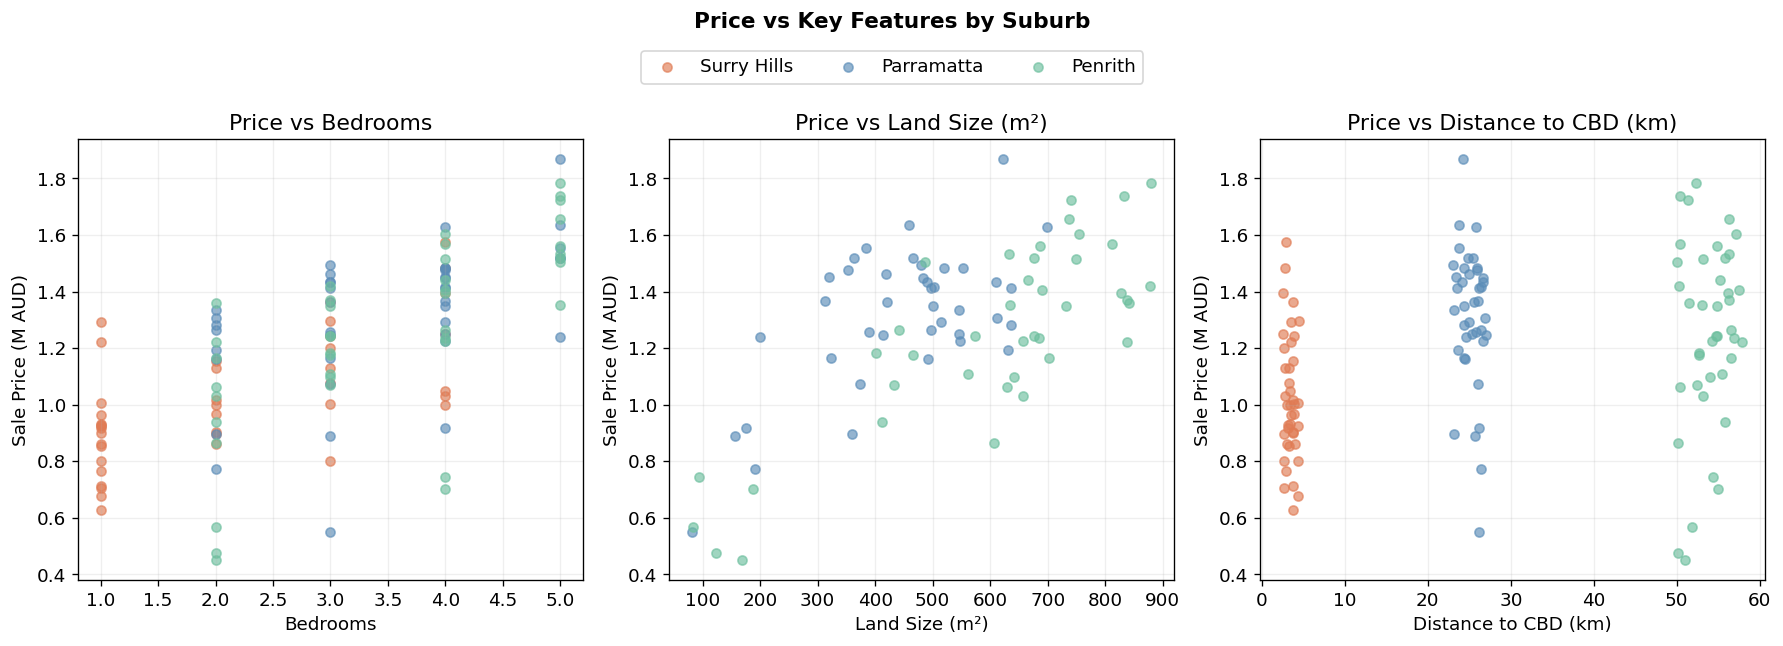

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (xcol, xlabel) in zip(axes, [
    ('bedrooms', 'Bedrooms'),
    ('land_size_m2', 'Land Size (m²)'),
    ('distance_to_cbd_km', 'Distance to CBD (km)'),
]):
    for suburb, color in SUBURB_PALETTE.items():
        sub = df[df['suburb'] == suburb]
        ax.scatter(sub[xcol], sub['sale_price_aud'] / 1e6, color=color,
                   alpha=0.65, s=30, label=suburb)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Sale Price (M AUD)')
    ax.set_title(f'Price vs {xlabel}')
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3)
plt.suptitle('Price vs Key Features by Suburb', fontsize=13, fontweight='bold', y=1.07)
plt.tight_layout()
plt.savefig(FIGURES / 'scatter_price_vs_features.png', bbox_inches='tight')
plt.show()

---
## 2.5  Time Trend — Price vs Sale Date

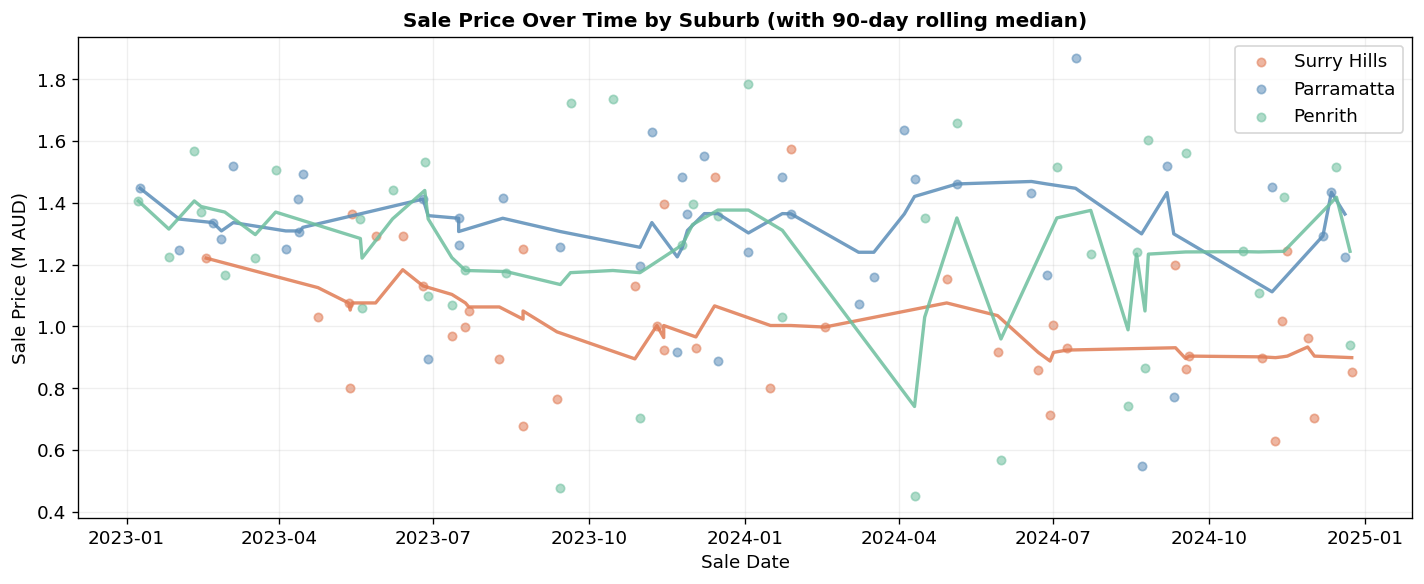

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
for suburb, color in SUBURB_PALETTE.items():
    sub = df[df['suburb'] == suburb].sort_values('sale_date')
    ax.scatter(sub['sale_date'], sub['sale_price_aud'] / 1e6,
               color=color, alpha=0.55, s=25, label=suburb)
    # Rolling median trend
    if len(sub) >= 5:
        sub_sorted = sub.set_index('sale_date')['sale_price_aud'].sort_index()
        rolling = sub_sorted.rolling('90D').median()
        ax.plot(rolling.index, rolling.values / 1e6, color=color, linewidth=2, alpha=0.85)

ax.set_xlabel('Sale Date')
ax.set_ylabel('Sale Price (M AUD)')
ax.set_title('Sale Price Over Time by Suburb (with 90-day rolling median)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(FIGURES / 'price_time_trend.png', bbox_inches='tight')
plt.show()

---
## 2.6  Correlation Heatmap

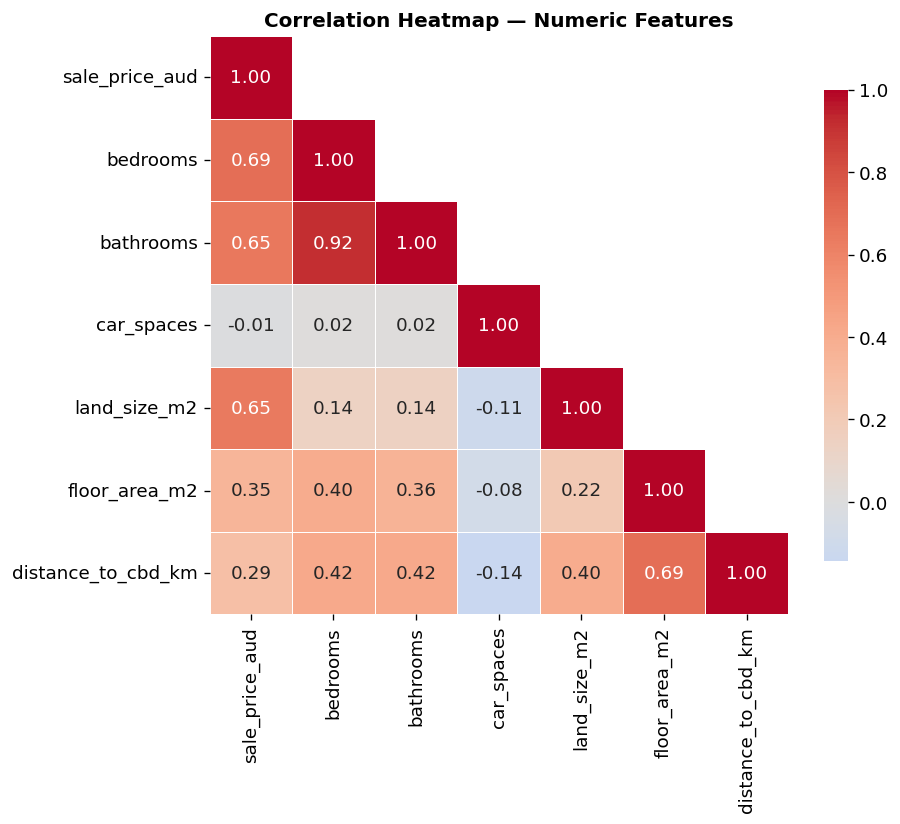

Top correlations with sale_price_aud:
bedrooms              0.691116
bathrooms             0.654832
land_size_m2          0.646473
floor_area_m2         0.349542
distance_to_cbd_km    0.285431
car_spaces            0.012626
Name: sale_price_aud, dtype: float64


In [6]:
numeric_cols = ['sale_price_aud', 'bedrooms', 'bathrooms', 'car_spaces',
                'land_size_m2', 'floor_area_m2', 'distance_to_cbd_km']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, mask=mask, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.75})
ax.set_title('Correlation Heatmap — Numeric Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Top correlations with sale_price_aud:')
print(corr['sale_price_aud'].drop('sale_price_aud').abs().sort_values(ascending=False))

---
## 2.7  Outlier Detection

In [7]:
# IQR rule
Q1 = df['sale_price_aud'].quantile(0.25)
Q3 = df['sale_price_aud'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = df[(df['sale_price_aud'] < Q1 - 1.5 * IQR) | (df['sale_price_aud'] > Q3 + 1.5 * IQR)]

# Z-score rule
z_scores = np.abs(stats.zscore(df['sale_price_aud']))
z_outliers = df[z_scores > 3]

print(f'IQR outliers (|price - median| > 1.5×IQR): {len(iqr_outliers)}')
print(f'Z-score outliers (|z| > 3): {len(z_outliers)}')

if len(iqr_outliers) > 0:
    print('\nIQR flagged records:')
    print(iqr_outliers[['suburb', 'property_type', 'bedrooms', 'land_size_m2', 'sale_price_aud']].to_string())

# Decision: retain all flagged records (they are plausible extremes, not data entry errors)
print('\nDecision: Retain all flagged records. Extreme prices in this dataset reflect genuine market variation')
print('(large land holdings, premium renovations). They will be discussed in the error analysis notebook.')

IQR outliers (|price - median| > 1.5×IQR): 0
Z-score outliers (|z| > 3): 0

Decision: Retain all flagged records. Extreme prices in this dataset reflect genuine market variation
(large land holdings, premium renovations). They will be discussed in the error analysis notebook.


---
## 2.8  Feature Engineering

In [8]:
# Apply shared feature engineering (from src/features.py)
reference_year = df['sale_date'].dt.year.max()  # use latest sale year as reference
df = engineer_features(df, reference_year=int(reference_year))

print('New features added:')
print(df[['property_age', 'bed_bath_ratio', 'price_per_m2', 'log_sale_price']].describe())

New features added:
       property_age  bed_bath_ratio  price_per_m2  log_sale_price
count    120.000000      120.000000     80.000000      120.000000
mean      26.183333        1.231944   2850.451393       13.957015
std       16.043524        0.320696   1280.880613        0.280894
min        0.000000        1.000000   1426.688633       13.021437
25%       11.750000        1.000000   2035.363142       13.781693
50%       24.000000        1.000000   2460.099159       14.028197
75%       38.000000        1.333333   3144.376639       14.163699
max       61.000000        2.000000   7914.893617       14.439843


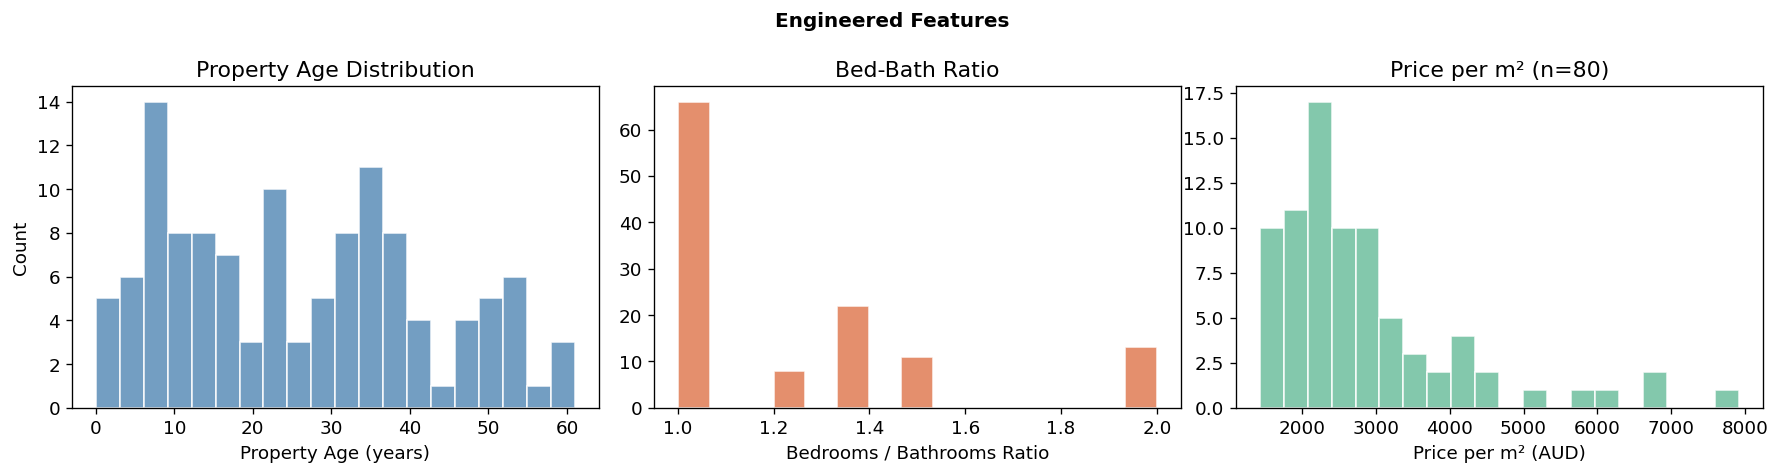

In [9]:
# Visualise engineered features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Property age distribution
axes[0].hist(df['property_age'], bins=20, color='#5B8DB8', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Property Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Property Age Distribution')

# Bed-bath ratio
axes[1].hist(df['bed_bath_ratio'].dropna(), bins=15, color='#E07B54', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Bedrooms / Bathrooms Ratio')
axes[1].set_title('Bed-Bath Ratio')

# Price per m² where available
ppm2_valid = df['price_per_m2'].dropna()
axes[2].hist(ppm2_valid, bins=20, color='#6DBF9E', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Price per m² (AUD)')
axes[2].set_title(f'Price per m² (n={len(ppm2_valid)})')

plt.suptitle('Engineered Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'engineered_features.png', bbox_inches='tight')
plt.show()

---
## 2.9  Preprocessing Pipeline Definition

The scikit-learn `Pipeline` + `ColumnTransformer` below is designed so that **imputation, scaling and encoding are fitted inside each cross-validation fold**, which prevents data leakage.

- **Numeric:** Median imputation → StandardScaler (where the model requires it)
- **Categorical:** Most-frequent imputation → OneHotEncoder (preserves no ordinal ordering)
- **Target:** log(sale_price_aud) is used; the inverse is applied at prediction time

In [10]:
from sklearn.linear_model import Ridge

preprocessor = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    scale_numerics=True,
)
print('Numeric features:', NUMERIC_FEATURES)
print('Categorical features:', CATEGORICAL_FEATURES)
print('Target: log(sale_price_aud) → inverse-transformed at prediction time')
print('\nPreprocessor summary:')
print(preprocessor)

Numeric features: ['bedrooms', 'bathrooms', 'car_spaces', 'land_size_m2', 'floor_area_m2', 'property_age', 'distance_to_cbd_km', 'bed_bath_ratio']
Categorical features: ['suburb', 'property_type']
Target: log(sale_price_aud) → inverse-transformed at prediction time

Preprocessor summary:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['bedrooms', 'bathrooms', 'car_spaces',
                                  'land_size_m2', 'floor_area_m2',
                                  'property_age', 'distance_to_cbd_km',
                                  'bed_bath_ratio']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='mos

---
## 2.10  Save Feature-Engineered Dataset

In [11]:
df.to_csv(PROCESSED_PATH, index=False)
print(f'Saved feature-engineered dataset to: {PROCESSED_PATH}')
print(f'Final columns: {list(df.columns)}')
print(f'Final shape: {df.shape}')

Saved feature-engineered dataset to: D:\Deakin\Machine Learning\ml\project\data\processed_dataset.csv
Final columns: ['suburb', 'postcode', 'property_type', 'bedrooms', 'bathrooms', 'car_spaces', 'land_size_m2', 'floor_area_m2', 'year_built', 'sale_date', 'distance_to_cbd_km', 'agent_description', 'sale_price_aud', 'source_url', 'property_age', 'bed_bath_ratio', 'price_per_m2', 'log_sale_price']
Final shape: (120, 18)


---
## Summary

**Key findings:**
- Sale price is right-skewed; log-transform substantially normalises it (skewness reduced).
- The three suburbs show clearly distinct price distributions — confirming they represent genuinely different markets.
- `distance_to_cbd_km` and `bedrooms` are the strongest numeric correlates of price.
- Outlier analysis flagged a small number of high-price properties; all are plausible and retained.
- Engineered features (`property_age`, `bed_bath_ratio`) add interpretable structure.

**Pre-analysis prediction review (partial):** The suburb effect is clearly visible in the box plots — confirming that prediction. Land size correlation is positive but only available for non-unit properties, limiting its reach.